In [72]:
%load_ext autoreload
%autoreload 0
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
import re,sys,os
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# Set font to Arial
matplotlib.rcParams['font.family'] = 'Arial'

# Optional: Set PDF to embed fonts (for Illustrator editing)
matplotlib.rcParams['pdf.fonttype'] = 42  # TrueType fonts for better editing

In [74]:
mspycloud_dir = Path(r"E:\lab\cptac-prostate\20260401_quality_control")
mspycloud_path = mspycloud_dir / "mspycloud_Global_DDA_TMT_Clean_MD.tsv"
mspycloud_df = pd.read_csv(mspycloud_path, sep="\t", index_col=0)
mspycloud_df

,Reference Sample 1,C3L-05292_T,C3L-09383_T,CHTN-43798_T,C3L-06261_N,C3L-08811_T,C3L-06506_N,C3L-07804_T,C3L-06595_T,C3L-06742_T,...,CHTN-44966_T,C3L-11192_N,C3L-08805_T,C3L-09760_T,C3L-08444_T,C3L-08291_T,C3L-10583_T,C3L-07877_T,C3L-08377_T,C3L-08736_T
Protein.Group.Accessions,,,,,,,,,,,,,,,,,,,,,
ENSP00000000233|ENST00000000233|ENSG00000004059|ARF5 ADP ribosylation factor 5,0.0,0.077017,-0.187993,-0.137950,-0.255903,0.235679,-0.122157,0.049047,-0.150472,0.090129,...,0.177651,-0.184215,-0.495843,0.065143,0.050001,0.262834,-0.221609,0.084544,-0.024535,0.266896
"ENSP00000000412|ENST00000000412|ENSG00000003056|M6PR mannose-6-phosphate receptor, cation dependent",0.0,0.122390,0.036646,0.179340,0.038353,0.361856,0.023644,-0.226568,-0.218785,-0.029380,...,-0.210005,-0.509339,0.323025,0.112554,-0.003882,-0.364879,-0.290935,0.175473,0.113948,0.242116
ENSP00000001008|ENST00000001008|ENSG00000004478|FKBP4 FKBP prolyl isomerase 4,0.0,-0.158774,-0.185559,-0.186552,-0.403156,0.400005,-0.286488,-0.581658,-0.184171,0.472634,...,-0.235445,-0.561989,-0.306163,0.162003,0.084839,0.157711,-0.421211,-0.058981,-0.186794,0.220484
ENSP00000002125|ENST00000002125|ENSG00000003509|NDUFAF7 NADH:ubiquinone oxidoreductase complex assembly factor 7,0.0,-0.007247,0.085730,-0.037076,-0.063520,0.155436,-0.019618,-0.203342,0.050553,-0.125149,...,-0.261797,0.020816,0.195666,0.066049,0.017390,-0.083763,0.028189,-0.052304,-0.023878,0.302151
ENSP00000002165|ENST00000002165|ENSG00000001036|FUCA2 alpha-L-fucosidase 2,0.0,0.075815,0.295018,0.097095,-0.751552,0.072959,-0.744420,-1.052637,-0.236417,0.532446,...,0.024258,-0.138183,-0.132877,0.102094,-0.293056,0.623585,-0.611337,-0.503879,0.224542,0.707597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSP00000307014|ENST00000305748|ENSG00000186049|KRT73 keratin 73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.705524,1.032750,-0.274949,-0.305077,0.167676,-0.272981,0.215760,0.833478,0.328482,-0.000854
"ENSP00000312070|ENST00000308177|ENSG00000240184|PCDHGC3 protocadherin gamma subfamily C, 3",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.016368,0.176268,0.339498,0.119363,0.172382,-0.108952,0.503057,0.065289,0.034634,-0.416416
ENSP00000452370|ENST00000557607|ENSG00000100722|ZC3H14 zinc finger CCCH-type containing 14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.492035,0.539346,-0.074879,-0.652922,-0.225059,0.028898,0.282637,-0.544384,0.020144,0.257734


In [75]:
def rename(name):
    items = name.split("|")
    p_name = items[0]
    t_name = items[1]
    g_name = items[2]
    gene_name = items[3].split(" ")[0]
    new_name = f"{g_name}_{gene_name}"
    return new_name
    

In [76]:
mspycloud_df.index = mspycloud_df.index.map(rename)

In [77]:
mspycloud_df

,Reference Sample 1,C3L-05292_T,C3L-09383_T,CHTN-43798_T,C3L-06261_N,C3L-08811_T,C3L-06506_N,C3L-07804_T,C3L-06595_T,C3L-06742_T,...,CHTN-44966_T,C3L-11192_N,C3L-08805_T,C3L-09760_T,C3L-08444_T,C3L-08291_T,C3L-10583_T,C3L-07877_T,C3L-08377_T,C3L-08736_T
Protein.Group.Accessions,,,,,,,,,,,,,,,,,,,,,
ENSG00000004059_ARF5,0.0,0.077017,-0.187993,-0.137950,-0.255903,0.235679,-0.122157,0.049047,-0.150472,0.090129,...,0.177651,-0.184215,-0.495843,0.065143,0.050001,0.262834,-0.221609,0.084544,-0.024535,0.266896
ENSG00000003056_M6PR,0.0,0.122390,0.036646,0.179340,0.038353,0.361856,0.023644,-0.226568,-0.218785,-0.029380,...,-0.210005,-0.509339,0.323025,0.112554,-0.003882,-0.364879,-0.290935,0.175473,0.113948,0.242116
ENSG00000004478_FKBP4,0.0,-0.158774,-0.185559,-0.186552,-0.403156,0.400005,-0.286488,-0.581658,-0.184171,0.472634,...,-0.235445,-0.561989,-0.306163,0.162003,0.084839,0.157711,-0.421211,-0.058981,-0.186794,0.220484
ENSG00000003509_NDUFAF7,0.0,-0.007247,0.085730,-0.037076,-0.063520,0.155436,-0.019618,-0.203342,0.050553,-0.125149,...,-0.261797,0.020816,0.195666,0.066049,0.017390,-0.083763,0.028189,-0.052304,-0.023878,0.302151
ENSG00000001036_FUCA2,0.0,0.075815,0.295018,0.097095,-0.751552,0.072959,-0.744420,-1.052637,-0.236417,0.532446,...,0.024258,-0.138183,-0.132877,0.102094,-0.293056,0.623585,-0.611337,-0.503879,0.224542,0.707597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000186049_KRT73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.705524,1.032750,-0.274949,-0.305077,0.167676,-0.272981,0.215760,0.833478,0.328482,-0.000854
ENSG00000240184_PCDHGC3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.016368,0.176268,0.339498,0.119363,0.172382,-0.108952,0.503057,0.065289,0.034634,-0.416416
ENSG00000100722_ZC3H14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.492035,0.539346,-0.074879,-0.652922,-0.225059,0.028898,0.282637,-0.544384,0.020144,0.257734


In [97]:
mspycloud_df.dropna().shape

(7731, 216)

In [78]:
msfragger_dir = Path(r"F:\lab\cptac_prostate\data\v4\CPTAC")
msfragger_path = msfragger_dir / "prostate_CPTAC_prot_TMT_ratio_gene_MD.tsv"
msfragger_df = pd.read_csv(msfragger_path, sep="\t", index_col=[0,1])
msfragger_df

,,C3L.05292.T,C3L.09383.T,CHTN.43798.T,C3L.06261.N,C3L.08811.T,C3L.06506.N,C3L.07804.T,C3L.06595.T,C3L.06742.T,CHTN.45205.T,...,C3L.07875.T,CHTN.44966.T,C3L.11192.N,C3L.08805.T,C3L.09760.T,C3L.08444.T,C3L.08291.T,C3L.10583.T,C3L.07877.T,C3L.08736.T
geneSymbol,Index,,,,,,,,,,,,,,,,,,,,,
TSPAN6,ENSG00000000003,0.246167,-0.232782,0.036682,0.385536,1.230384,-0.572865,0.061034,-0.310428,-0.586053,-0.163240,...,-0.125180,-0.445058,-1.381942,-0.639527,0.124744,0.730739,0.224078,0.609170,-1.463087,0.171265
DPM1,ENSG00000000419,0.087491,0.006727,0.153783,0.125006,-0.079821,0.017159,0.198838,0.013154,0.167225,0.184560,...,0.101158,-0.040446,-0.048161,-0.418291,0.049782,0.020079,0.206712,-0.089707,0.275949,0.771013
SCYL3,ENSG00000000457,-0.007697,0.227025,0.126562,-0.090885,0.158945,0.171964,0.018928,0.211646,0.013627,-0.113480,...,-0.097320,0.155888,0.117014,-0.317737,-0.073313,0.262235,-0.117545,-0.122938,0.001625,0.004418
C1orf112,ENSG00000000460,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CFH,ENSG00000000971,-1.356326,0.041234,-0.970196,0.642465,0.094045,0.069982,0.218794,-0.208355,0.370142,-0.517100,...,0.371712,-0.307495,-0.441050,0.029135,-0.392532,-0.356210,-0.504270,0.794966,0.340036,-0.820125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000289694,ENSG00000289694,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000289697,ENSG00000289697,-0.663468,0.109184,0.056996,0.552624,-0.052598,0.640618,0.195310,0.239897,0.203662,-0.026909,...,-0.017375,0.276273,0.040550,0.477576,-0.099907,-0.415738,-0.229682,0.830784,0.071162,-0.514345
HOMEZ,ENSG00000290292,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
def rename2(name):
    gene_name, g_name = name
    new_name = f"{g_name}_{gene_name}"
    return new_name

In [80]:
msfragger_df.index = msfragger_df.index.map(rename2)
msfragger_df

,C3L.05292.T,C3L.09383.T,CHTN.43798.T,C3L.06261.N,C3L.08811.T,C3L.06506.N,C3L.07804.T,C3L.06595.T,C3L.06742.T,CHTN.45205.T,...,C3L.07875.T,CHTN.44966.T,C3L.11192.N,C3L.08805.T,C3L.09760.T,C3L.08444.T,C3L.08291.T,C3L.10583.T,C3L.07877.T,C3L.08736.T
ENSG00000000003_TSPAN6,0.246167,-0.232782,0.036682,0.385536,1.230384,-0.572865,0.061034,-0.310428,-0.586053,-0.163240,...,-0.125180,-0.445058,-1.381942,-0.639527,0.124744,0.730739,0.224078,0.609170,-1.463087,0.171265
ENSG00000000419_DPM1,0.087491,0.006727,0.153783,0.125006,-0.079821,0.017159,0.198838,0.013154,0.167225,0.184560,...,0.101158,-0.040446,-0.048161,-0.418291,0.049782,0.020079,0.206712,-0.089707,0.275949,0.771013
ENSG00000000457_SCYL3,-0.007697,0.227025,0.126562,-0.090885,0.158945,0.171964,0.018928,0.211646,0.013627,-0.113480,...,-0.097320,0.155888,0.117014,-0.317737,-0.073313,0.262235,-0.117545,-0.122938,0.001625,0.004418
ENSG00000000460_C1orf112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000000971_CFH,-1.356326,0.041234,-0.970196,0.642465,0.094045,0.069982,0.218794,-0.208355,0.370142,-0.517100,...,0.371712,-0.307495,-0.441050,0.029135,-0.392532,-0.356210,-0.504270,0.794966,0.340036,-0.820125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000289694_ENSG00000289694,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000289697_ENSG00000289697,-0.663468,0.109184,0.056996,0.552624,-0.052598,0.640618,0.195310,0.239897,0.203662,-0.026909,...,-0.017375,0.276273,0.040550,0.477576,-0.099907,-0.415738,-0.229682,0.830784,0.071162,-0.514345
ENSG00000290292_HOMEZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000290315_ENSG00000290315,-0.028047,-0.031816,-0.134945,-0.092415,0.348046,-0.131648,-0.001906,-0.026499,0.883568,0.168023,...,0.033842,-0.339236,-0.073002,-0.154825,-0.062641,-0.067995,-0.098637,-0.236691,-0.304321,-0.129953


In [81]:
def sample_rename(name):
    items = name.split(".")
    a = items[0]
    b = items[1]
    c = items[2]
    new_name = f"{a}-{b}_{c}"
    return new_name

In [82]:
cols = [sample_rename(i) for i in msfragger_df.columns]

In [83]:
msfragger_df.columns = cols

In [84]:
msfragger_df

,C3L-05292_T,C3L-09383_T,CHTN-43798_T,C3L-06261_N,C3L-08811_T,C3L-06506_N,C3L-07804_T,C3L-06595_T,C3L-06742_T,CHTN-45205_T,...,C3L-07875_T,CHTN-44966_T,C3L-11192_N,C3L-08805_T,C3L-09760_T,C3L-08444_T,C3L-08291_T,C3L-10583_T,C3L-07877_T,C3L-08736_T
ENSG00000000003_TSPAN6,0.246167,-0.232782,0.036682,0.385536,1.230384,-0.572865,0.061034,-0.310428,-0.586053,-0.163240,...,-0.125180,-0.445058,-1.381942,-0.639527,0.124744,0.730739,0.224078,0.609170,-1.463087,0.171265
ENSG00000000419_DPM1,0.087491,0.006727,0.153783,0.125006,-0.079821,0.017159,0.198838,0.013154,0.167225,0.184560,...,0.101158,-0.040446,-0.048161,-0.418291,0.049782,0.020079,0.206712,-0.089707,0.275949,0.771013
ENSG00000000457_SCYL3,-0.007697,0.227025,0.126562,-0.090885,0.158945,0.171964,0.018928,0.211646,0.013627,-0.113480,...,-0.097320,0.155888,0.117014,-0.317737,-0.073313,0.262235,-0.117545,-0.122938,0.001625,0.004418
ENSG00000000460_C1orf112,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000000971_CFH,-1.356326,0.041234,-0.970196,0.642465,0.094045,0.069982,0.218794,-0.208355,0.370142,-0.517100,...,0.371712,-0.307495,-0.441050,0.029135,-0.392532,-0.356210,-0.504270,0.794966,0.340036,-0.820125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000289694_ENSG00000289694,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000289697_ENSG00000289697,-0.663468,0.109184,0.056996,0.552624,-0.052598,0.640618,0.195310,0.239897,0.203662,-0.026909,...,-0.017375,0.276273,0.040550,0.477576,-0.099907,-0.415738,-0.229682,0.830784,0.071162,-0.514345
ENSG00000290292_HOMEZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENSG00000290315_ENSG00000290315,-0.028047,-0.031816,-0.134945,-0.092415,0.348046,-0.131648,-0.001906,-0.026499,0.883568,0.168023,...,0.033842,-0.339236,-0.073002,-0.154825,-0.062641,-0.067995,-0.098637,-0.236691,-0.304321,-0.129953


In [96]:
msfragger_df.dropna()

,C3L-05292_T,C3L-09383_T,CHTN-43798_T,C3L-06261_N,C3L-08811_T,C3L-06506_N,C3L-07804_T,C3L-06595_T,C3L-06742_T,CHTN-45205_T,...,C3L-07875_T,CHTN-44966_T,C3L-11192_N,C3L-08805_T,C3L-09760_T,C3L-08444_T,C3L-08291_T,C3L-10583_T,C3L-07877_T,C3L-08736_T
ENSG00000000003_TSPAN6,0.246167,-0.232782,0.036682,0.385536,1.230384,-0.572865,0.061034,-0.310428,-0.586053,-0.163240,...,-0.125180,-0.445058,-1.381942,-0.639527,0.124744,0.730739,0.224078,0.609170,-1.463087,0.171265
ENSG00000000419_DPM1,0.087491,0.006727,0.153783,0.125006,-0.079821,0.017159,0.198838,0.013154,0.167225,0.184560,...,0.101158,-0.040446,-0.048161,-0.418291,0.049782,0.020079,0.206712,-0.089707,0.275949,0.771013
ENSG00000000457_SCYL3,-0.007697,0.227025,0.126562,-0.090885,0.158945,0.171964,0.018928,0.211646,0.013627,-0.113480,...,-0.097320,0.155888,0.117014,-0.317737,-0.073313,0.262235,-0.117545,-0.122938,0.001625,0.004418
ENSG00000000971_CFH,-1.356326,0.041234,-0.970196,0.642465,0.094045,0.069982,0.218794,-0.208355,0.370142,-0.517100,...,0.371712,-0.307495,-0.441050,0.029135,-0.392532,-0.356210,-0.504270,0.794966,0.340036,-0.820125
ENSG00000001036_FUCA2,0.132835,0.207359,0.135986,-0.647224,0.172049,-0.760730,-0.870467,-0.254506,0.444387,0.165997,...,0.154154,-0.151535,-0.456293,-0.256156,0.131682,-0.282375,0.639959,-0.627785,-0.318943,0.898515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000288796_ENSG00000288796,-1.068650,0.417497,-1.231578,-0.530920,-0.639223,0.648059,-1.358671,0.233100,-1.348565,-0.207924,...,-0.411718,-0.681520,-0.187508,-0.753332,-1.003439,-0.204751,-0.688342,1.252445,-0.843930,-1.300777
ENSG00000289027_ENSG00000289027,0.072731,-0.120512,0.531986,0.003065,-0.086533,0.441264,0.369004,0.183412,-0.311955,0.016014,...,0.076955,-0.178163,-0.055852,0.174857,0.129082,0.455865,0.244800,-0.142812,0.239893,0.150398
ENSG00000289697_ENSG00000289697,-0.663468,0.109184,0.056996,0.552624,-0.052598,0.640618,0.195310,0.239897,0.203662,-0.026909,...,-0.017375,0.276273,0.040550,0.477576,-0.099907,-0.415738,-0.229682,0.830784,0.071162,-0.514345
ENSG00000290315_ENSG00000290315,-0.028047,-0.031816,-0.134945,-0.092415,0.348046,-0.131648,-0.001906,-0.026499,0.883568,0.168023,...,0.033842,-0.339236,-0.073002,-0.154825,-0.062641,-0.067995,-0.098637,-0.236691,-0.304321,-0.129953


In [85]:
sample = "C3L-05292_T"

In [86]:
out_dir = Path(r"E:\lab\cptac-prostate\20260401_comp_search_global_dda_tmt")
out_dir.mkdir(exist_ok=True)

In [87]:
plots_dir  = out_dir / "plots"
plots_dir.mkdir(exist_ok=True)



In [88]:
def plot_bland_altman(df,sample, out_dir):
    df2 = df.dropna(subset=["MSFragger", "MSPycloud"]).copy()

    df2["mean"] = (df2["MSFragger"] + df2["MSPycloud"]) / 2
    df2["signed_diff"] = df2["MSFragger"] - df2["MSPycloud"]

    sns.scatterplot(
        x="mean",
        y="signed_diff",
        data=df2,
        alpha=0.3
    )

    plt.axhline(df2["signed_diff"].mean(), color="red")
    plt.savefig(out_dir / f"{sample}_bland_altman_plot.png", 
                dpi=300, bbox_inches='tight')
    plt.close()

In [89]:
def plot_corr(sample,corr,df2, out_dir):
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(6,6))

    sns.regplot(
        data=df2,
        x="MSFragger",
        y="MSPycloud",
        scatter_kws={"s":10, "alpha":0.5},
        line_kws={"color":"red"}
    )

    plt.title(f"Correlation r = {corr:.3f}")
    plt.xlabel(f"MSFragger: {sample}")
    plt.ylabel(f"MSPycloud: {sample}")

    plt.savefig(out_dir / f"{sample}_correlation_plot.png", 
                dpi=300, bbox_inches='tight')
    plt.close()
    
def qc_sample(sample):
    a = msfragger_df[sample].to_dict()
    b = mspycloud_df[sample].to_dict()
    proteins = set(a.keys()) & set(b.keys())
    df = pd.DataFrame({
        "MSFragger": [a[i] for i in sorted(proteins)],
        "MSPycloud": [b[i] for i in sorted(proteins)],
        "Protein": sorted(proteins)
    })
    df2 = df.dropna(subset=["MSFragger", "MSPycloud"])
    corr = df2["MSFragger"].corr(df2["MSPycloud"], method="pearson")
    # print("Pearson r =", corr)
    plot_corr(sample, corr, df2,plots_dir)
    
    df2['diff'] = abs(df2["MSFragger"] - df2["MSPycloud"])
    description = dict(df2['diff'].describe())
    
    rmse = np.sqrt(np.mean((df2["MSFragger"] - df2["MSPycloud"])**2))
    
    plot_bland_altman(df2,sample, plots_dir)

    return corr, rmse, description

In [90]:
rows = []
for sample in tqdm(msfragger_df.columns):
    corr,rmse, description = qc_sample(sample)
    rows.append({"Sample": sample, 
                 "Correlation": corr,
                 "RMSE": rmse,
                 **description})
analysis_df = pd.DataFrame(rows)

  0%|          | 0/178 [00:00<?, ?it/s]C:\Users\yhu39\AppData\Local\Temp\ipykernel_19216\4165036240.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['diff'] = abs(df2["MSFragger"] - df2["MSPycloud"])
  1%|          | 1/178 [00:00<01:20,  2.19it/s]C:\Users\yhu39\AppData\Local\Temp\ipykernel_19216\4165036240.py:37: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['diff'] = abs(df2["MSFragger"] - df2["MSPycloud"])
  1%|          | 2/178 [00:00<01:20,  2.20it/s]C:\Users\yhu39\AppData\Local\Temp\ipykern

In [91]:
analysis_df.to_csv(out_dir / "20260401_search_comp_summary.csv", index=False)

In [92]:
analysis_df

,Sample,Correlation,RMSE,count,mean,std,min,25%,50%,75%,max
0,C3L-05292_T,0.872438,0.186071,8350.0,0.099009,0.157552,7.779903e-08,0.016442,0.050757,0.116771,4.193856
1,C3L-09383_T,0.820594,0.190851,8349.0,0.105055,0.159344,1.616722e-05,0.024381,0.058299,0.124622,3.901654
2,CHTN-43798_T,0.798788,0.258079,8347.0,0.118469,0.229295,5.925957e-06,0.031303,0.069909,0.140534,15.014013
3,C3L-06261_N,0.855240,0.192001,8351.0,0.100842,0.163397,8.084901e-06,0.025108,0.057550,0.118076,5.827587
4,C3L-08811_T,0.802488,0.219972,8350.0,0.129992,0.177464,5.278989e-06,0.029877,0.072506,0.160188,2.533784
...,...,...,...,...,...,...,...,...,...,...,...
173,C3L-08444_T,0.798069,0.190736,8365.0,0.088807,0.168811,4.953235e-06,0.019534,0.045222,0.097372,5.943993
174,C3L-08291_T,0.857575,0.247241,8366.0,0.136430,0.206203,1.306660e-05,0.028285,0.072280,0.160083,4.532091
175,C3L-10583_T,0.832635,0.228625,8366.0,0.127549,0.189749,6.770825e-09,0.030526,0.071298,0.149968,6.280985
176,C3L-07877_T,0.824122,0.180661,8365.0,0.094871,0.153755,2.362150e-06,0.023513,0.052193,0.107269,4.145210


In [93]:
analysis_df['percent_error'] = analysis_df['RMSE'].apply(lambda x: (2 ** x - 1) * 100)

(0.0, 100.0)

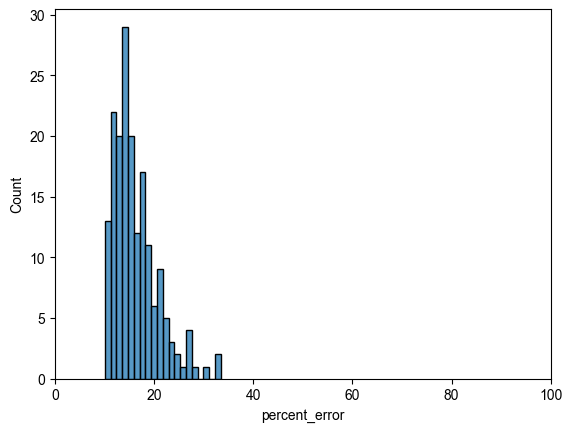

In [100]:
sns.histplot(analysis_df['percent_error'], bins=20)
plt.xlim(0, 100)

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.histplot(analysis_df['percent_error'], bins=20)

plt.xlabel("percent_error")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig(out_dir / "percent_error_hist.png", dpi=300)

plt.close()